In [4]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

# Load datasets

In [5]:
home = "../.."
project_name = "vinarun"
os.makedirs(f"{home}/notebooks/analysis/specificity_figures", exist_ok=True)
os.makedirs(f"{home}/notebooks/analysis/raw_values", exist_ok=True)

In [6]:
#scores_table = pd.read_csv(f"{home}/data/{project_name}/rp_scores.txt", sep="\t").drop_duplicates()
scores_table = pd.read_csv(f"{home}/notebooks/analysis/data/scores_combined.txt", sep="\t").drop_duplicates()
annotation_table = pd.read_csv(f"{home}/guild/support/annotated_gpcrdb.csv", sep="\t")

/tmp/ipykernel_143359/3349143520.py:2: DtypeWarning: Columns (0,9) have mixed types. Specify dtype option on import or set low_memory=False.
  scores_table = pd.read_csv(f"{home}/notebooks/analysis/data/scores_combined.txt", sep="\t").drop_duplicates()


In [7]:
print(f"Before dropping NA: {len(scores_table)}")
scores_table = scores_table.dropna(subset=["vina_score"])
print(f"After dropping NA: {len(scores_table)}")

Before dropping NA: 402260
After dropping NA: 300974


In [8]:
# ── Exclude proteins ──────────────────────────────────────────────────────────
EXCLUDE_PROTEINS = {"7v6a", "8fx5", "8wrz", "8wu1", "8dzs"}

scores_table["pdb_id"] = scores_table["protein_config_id"].str.split("-").str[0]
scores_table = scores_table[~scores_table["pdb_id"].isin(EXCLUDE_PROTEINS)].copy()
print(f"After excluding {EXCLUDE_PROTEINS}: {len(scores_table):,} rows")

After excluding {'8fx5', '7v6a', '8wrz', '8dzs', '8wu1'}: 289,869 rows


# Add family to df

In [9]:
annotated_scores_table = pd.merge(scores_table, annotation_table[["pdb_id", "family", "parent_family", "sub_family", "final_family"]], on="pdb_id", how="left")
annotated_scores_table = annotated_scores_table.sort_values(by="ligand_category")
ligand_category_mapper = annotated_scores_table[["ligand_id", "ligand_category"]].drop_duplicates().set_index("ligand_id").to_dict()["ligand_category"]

In [10]:
annotated_scores_table["ligand_category"].value_counts()

ligand_category
decoy              101670
Synthetic           99327
Natural Product     98416
weak-binder           435
strong-binder         345
Name: count, dtype: int64

In [11]:

np_synthetic_scores_table = annotated_scores_table[annotated_scores_table["ligand_category"].isin(["Natural Product", "Synthetic", "decoy"])]
np_compounds_list = annotated_scores_table[annotated_scores_table["ligand_category"] == "Natural Product"]["ligand_id"].unique()
synthetic_compounds_list = annotated_scores_table[annotated_scores_table["ligand_category"] == "Synthetic"]["ligand_id"].unique()
weak_binder_compounds_list = annotated_scores_table[annotated_scores_table["ligand_category"] == "weak-binder"]["ligand_id"].unique()
strong_binder_compounds_list = annotated_scores_table[annotated_scores_table["ligand_category"] == "strong-binder"]["ligand_id"].unique()
decoy_compounds_list = annotated_scores_table[annotated_scores_table["ligand_category"] == "decoy"]["ligand_id"].unique()

## Overall distribution

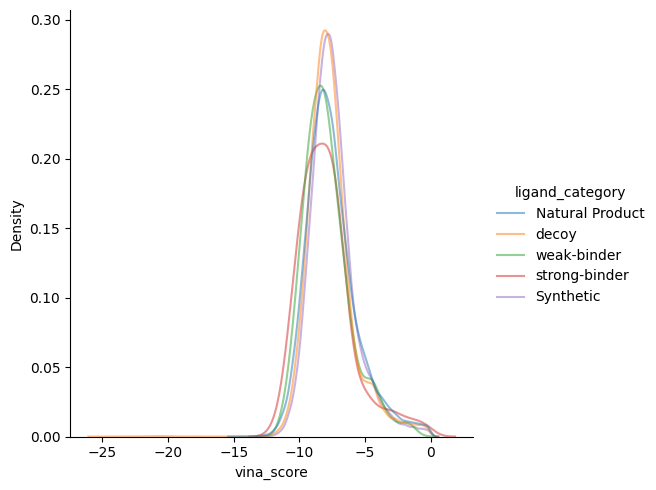

In [12]:
no_scores_above_0 = scores_table[scores_table["vina_score"] < 0.0]
sns.displot(no_scores_above_0, x="vina_score", hue="ligand_category", kind="kde", common_norm=False, fill=False, alpha=0.5)
# save the plot
plt.savefig("raw_values/no_scores_above_0.png", dpi=600, bbox_inches="tight")

In [13]:
## Per-protein distributions with known binders as vertical lines

In [14]:
os.makedirs("per_protein_distributions", exist_ok=True)

# Prepare data: only negative scores
plot_df = annotated_scores_table[annotated_scores_table["vina_score"] < 0.0].copy()

# Categories for KDE
kde_categories = ["Natural Product", "Synthetic", "decoy"]
kde_colors = {
    "Natural Product": "#1f77b4",
    "Synthetic": "#ff7f0e",
    "decoy": "#2ca02c",
}

# Binder categories for vertical lines
binder_categories = {
    "strong-binder": {"color": "#9467bd", "ls": "-", "label": "strong-binder"},
    "weak-binder": {"color": "#d62728", "ls": "--", "label": "weak-binder"},
}

proteins = sorted(plot_df["pdb_id"].unique())


# Top-K composition (NP vs Synthetic + Decoy)

For each protein, compute how many NPs vs non-NPs (synthetics + decoys) appear in the top fraction of ranked compounds.
This helps interpret whether NPs tend to dominate the top of the ranked list.

In [15]:
import matplotlib as mpl
import matplotlib.ticker as mticker

# ── Shared constants ──────────────────────────────────────────────────────────
K_VALUES = [0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
BASE_CATEGORIES = ["Natural Product", "Synthetic", "decoy"]
PANEL_SPECS = [
    ("np_enrichment",    "Natural products", "#00AB86"),
    ("syn_enrichment",   "Synthetics",       "#ECAE00"),
    ("decoy_enrichment", "Decoys",           "#0086C0"),
]
YMAX = 3.0

MPL_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7, "axes.titlesize": 8, "axes.titleweight": "bold",
    "axes.labelsize": 7, "xtick.labelsize": 6.5, "ytick.labelsize": 6.5,
    "legend.fontsize": 6.5, "axes.linewidth": 0.5,
    "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "xtick.direction": "out", "ytick.direction": "out",
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "savefig.transparent": False, "figure.dpi": 150,
}


# ── Helper: top-k composition per protein ─────────────────────────────────────
def topk_composition_per_protein(df, score_col="vina_score", higher_is_better=False, top_frac=0.01):
    sub = df[df["ligand_category"].isin(BASE_CATEGORIES)].copy()
    ascending = not higher_is_better
    top_dictionary = {}
    for pdb_id, grp in sub.groupby("pdb_id"):
        grp_sorted = grp.sort_values(score_col, ascending=ascending)
        n = len(grp_sorted)
        top_hits = max(1, int(np.ceil(top_frac * n)))
        top = grp_sorted.iloc[:top_hits]
        np_in = int((top["ligand_category"] == "Natural Product").sum())
        syn_in = int((top["ligand_category"] == "Synthetic").sum())
        dec_in = int((top["ligand_category"] == "decoy").sum())
        top_dictionary[pdb_id] = {
            "pdb_id": pdb_id,
            "final_family": grp_sorted["final_family"].iloc[0] if "final_family" in grp_sorted.columns else None,
            "total hits": n, "top hits": top_hits, "top_frac": top_frac,
            "top_np_frac": np_in / top_hits,
            "top_syn_frac": syn_in / top_hits,
            "top_decoy_frac": dec_in / top_hits,
        }
    return pd.DataFrame(top_dictionary.values())


# ── Helper: compute enrichment DataFrame ──────────────────────────────────────
def compute_enrichment(df, score_col="vina_score", higher_is_better=False):
    """Compute per-protein enrichment at multiple top-k cutoffs."""
    base = df[df["ligand_category"].isin(BASE_CATEGORIES)].copy()
    bc = base.groupby(["pdb_id", "ligand_category"]).size().unstack(fill_value=0)
    bf = bc.div(bc.sum(axis=1), axis=0).reset_index().rename(columns={
        "Natural Product": "baseline_np_frac",
        "Synthetic": "baseline_syn_frac",
        "decoy": "baseline_decoy_frac",
    })
    frames = []
    for k in K_VALUES:
        topk = topk_composition_per_protein(df, score_col=score_col, higher_is_better=higher_is_better, top_frac=k)
        topk = topk[["pdb_id", "final_family", "top_np_frac", "top_syn_frac", "top_decoy_frac"]].copy()
        topk["k"] = k
        topk = topk.merge(bf[["pdb_id", "baseline_np_frac", "baseline_syn_frac", "baseline_decoy_frac"]], on="pdb_id", how="left")
        topk["np_enrichment"]    = np.where(topk["baseline_np_frac"]    > 0, topk["top_np_frac"]    / topk["baseline_np_frac"],    np.nan)
        topk["syn_enrichment"]   = np.where(topk["baseline_syn_frac"]   > 0, topk["top_syn_frac"]   / topk["baseline_syn_frac"],   np.nan)
        topk["decoy_enrichment"] = np.where(topk["baseline_decoy_frac"] > 0, topk["top_decoy_frac"] / topk["baseline_decoy_frac"], np.nan)
        frames.append(topk)
    out = pd.concat(frames, ignore_index=True)
    out["k_pct"] = out["k"] * 100
    return out


# ── Helper: plot enrichment figure ────────────────────────────────────────────
def plot_enrichment(enrichment_df, title="Top-k enrichment", save_prefix=None):
    """Publication-ready 3-panel enrichment figure."""
    mpl.rcParams.update(mpl.rcParamsDefault)
    mpl.rcParams.update(MPL_STYLE)

    fig, axes = plt.subplots(3, 1, figsize=(3.4, 4.8), sharex=True, sharey=True,
                             gridspec_kw={"hspace": 0.40})
    labels = ["A)", "B)", "C)"]

    for idx, (ax, (col, panel_title, color)) in enumerate(zip(axes, PANEL_SPECS, strict=False)):
        pdf = enrichment_df.dropna(subset=[col])
        for _, grp in pdf.groupby("pdb_id"):
            grp = grp.sort_values("k_pct")
            ax.plot(grp["k_pct"], grp[col].clip(upper=YMAX),
                    color=color, alpha=0.08, linewidth=0.35, rasterized=True)

        summary = pdf.groupby("k_pct")[col].agg(
            median="median",
            q25=lambda x: np.quantile(x, 0.25),
            q75=lambda x: np.quantile(x, 0.75),
        ).reset_index()
        ax.fill_between(summary["k_pct"], summary["q25"], summary["q75"],
                        color=color, alpha=0.25, linewidth=0)
        ax.plot(summary["k_pct"], summary["median"],
                color=color, linewidth=1.4, solid_capstyle="round")

        ax.axhline(1.0, color="0.35", linestyle="--", linewidth=0.5, zorder=0)
        ax.set_title(f"{labels[idx]}  {panel_title}", fontsize=7.5, fontweight="bold", loc="center")
        ax.set_ylim(-0.15, YMAX + 0.15)
        ax.set_xlim(0, 52)
        ax.yaxis.set_major_locator(mticker.FixedLocator([0, 1, 2, 3]))
        ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if idx < 2:
            ax.tick_params(axis="x", labelbottom=False)
        else:
            ax.set_xlabel("Top-k (%)", labelpad=4)
            ax.set_xticks([k * 100 for k in K_VALUES])

    fig.text(0.005, 0.5, "Enrichment factor", va="center", ha="left",
             rotation="vertical", fontsize=7)
    fig.subplots_adjust(left=0.14, bottom=0.12)
    fig.legend(
        handles=[Line2D([0], [0], color=c, linewidth=1.4, label=t) for _, t, c in PANEL_SPECS],
        loc="lower center", ncol=3, bbox_to_anchor=(0.50, -0.02),
        frameon=False, columnspacing=1.0, handlelength=1.5,
    )
    if title:
        fig.suptitle(title, fontsize=9, fontweight="bold", y=1.01)
    if save_prefix:
        for ext in ("png", "pdf", "svg"):
            fig.savefig(f"{save_prefix}.{ext}", dpi=600, bbox_inches="tight")
    plt.show()
    return fig

In [16]:
os.makedirs("per_protein_distributions", exist_ok=True)
enrichment_df = compute_enrichment(annotated_scores_table, score_col="vina_score", higher_is_better=False)
print(f"Vina enrichment rows: {len(enrichment_df):,}")

Vina enrichment rows: 721


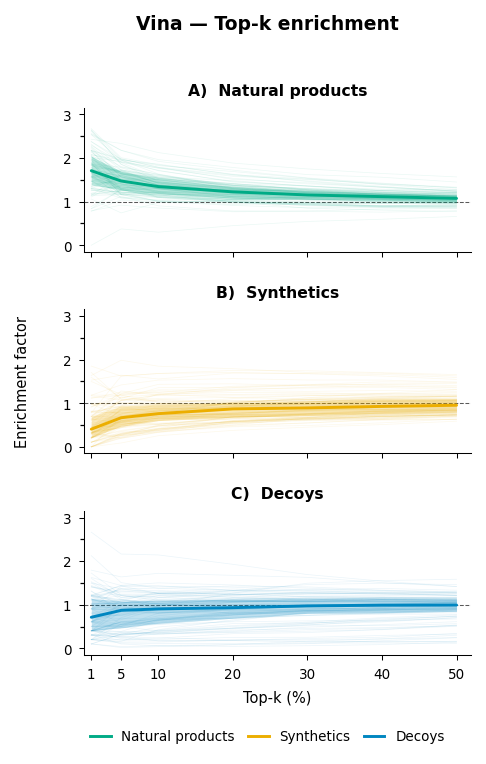

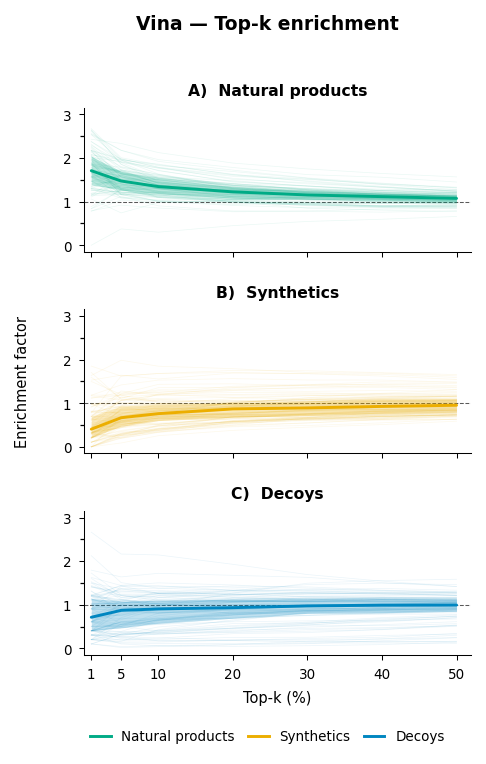

In [17]:
plot_enrichment(
    enrichment_df,
    title="Vina — Top-k enrichment",
    save_prefix="per_protein_distributions/figure_4_topk_enrichment_panel_np_syn_decoy",
)

## Top-k enrichment trajectories (panel: NP, Synthetic, Decoy)

For each protein and each top-k cutoff, enrichment is computed as:

$enrichment = top\_k\_fraction / baseline\_fraction\_in\_that\_protein$

Values above 1 indicate over-representation in the top-k compared with the protein-specific baseline.

---
# DiffDock Score Analysis

Equivalent analysis to the Vina sections above, now using **DiffDock confidence scores**.
DiffDock confidence scores range from ~−6 to ~0.8, where **higher = better**.

Data source: `diffdock_results_combined.csv` — DiffDock results across 100 shards.


In [21]:
# ── Load DiffDock scores ───────────────────────────────────────────────────────
DIFFDOCK_PATH = f"{home}/notebooks/analysis/data/diffdock_results_combined/diffdock_results_combined.csv"

dd_scores = pd.read_csv(DIFFDOCK_PATH).drop_duplicates()
dd_scores["pdb_id"] = dd_scores["protein_config_id"].str.split("-").str[0]

# Exclude same proteins as Vina
dd_scores = dd_scores[~dd_scores["pdb_id"].isin(EXCLUDE_PROTEINS)].copy()
dd_scores = dd_scores.dropna(subset=["diffdock_score"])

# Annotate with GPCR families
dd_annotated = pd.merge(
    dd_scores,
    annotation_table[["pdb_id", "family", "parent_family", "sub_family", "final_family"]],
    on="pdb_id", how="left",
)
dd_annotated = dd_annotated.sort_values(by="ligand_category")

print(f"DiffDock rows (after exclusions): {len(dd_annotated):,}")
print(f"Proteins: {dd_annotated['pdb_id'].nunique()}")
print(dd_annotated["ligand_category"].value_counts())


FileNotFoundError: [Errno 2] No such file or directory: '/home/antonio.gomes/Dockwizard/data/npsvinarun/vina_rescore_all.tsv'

## Overall DiffDock distribution

In [ ]:
sns.displot(dd_annotated, x="diffdock_score", hue="ligand_category", kind="kde",
            common_norm=False, fill=False, alpha=0.5)
plt.savefig("raw_values/diffdock_overall_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

## Top-K enrichment (DiffDock — Vina Rescore)

Same enrichment analysis as Vina, using `diffdock_score` (Vina rescore of DiffDock poses, lower = better).

In [ ]:
os.makedirs("per_protein_distributions/diffdock", exist_ok=True)
dd_enrichment_df = compute_enrichment(dd_annotated, score_col="diffdock_score", higher_is_better=True)
print(f"DiffDock enrichment rows: {len(dd_enrichment_df):,}")


In [ ]:
plot_enrichment(
    dd_enrichment_df,
    title="DiffDock — Top-k enrichment",
    save_prefix="per_protein_distributions/diffdock/figure_topk_enrichment_diffdock_rescored",
)

In [ ]:
# ── Vina vs DiffDock enrichment comparison ─────────────────────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update(MPL_STYLE)

fig, axes = plt.subplots(3, 1, figsize=(3.4, 4.8), sharex=True, sharey=True,
                         gridspec_kw={"hspace": 0.40})
labels = ["A)", "B)", "C)"]

for idx, (ax, (col, panel_title, color)) in enumerate(zip(axes, PANEL_SPECS, strict=False)):
    # Vina median + IQR
    v_summary = enrichment_df.dropna(subset=[col]).groupby("k_pct")[col].agg(
        median="median", q25=lambda x: np.quantile(x, 0.25), q75=lambda x: np.quantile(x, 0.75),
    ).reset_index()
    # DiffDock median + IQR
    d_summary = dd_enrichment_df.dropna(subset=[col]).groupby("k_pct")[col].agg(
        median="median", q25=lambda x: np.quantile(x, 0.25), q75=lambda x: np.quantile(x, 0.75),
    ).reset_index()

    ax.fill_between(v_summary["k_pct"], v_summary["q25"], v_summary["q75"],
                    color=color, alpha=0.15, linewidth=0)
    ax.plot(v_summary["k_pct"], v_summary["median"],
            color=color, linewidth=1.4, solid_capstyle="round", label="Vina")

    ax.fill_between(d_summary["k_pct"], d_summary["q25"], d_summary["q75"],
                    color=color, alpha=0.15, linewidth=0, hatch="///")
    ax.plot(d_summary["k_pct"], d_summary["median"],
            color=color, linewidth=1.4, linestyle="--", solid_capstyle="round", label="DiffDock")

    ax.axhline(1.0, color="0.35", linestyle=":", linewidth=0.5, zorder=0)
    ax.set_title(f"{labels[idx]}  {panel_title}", fontsize=7.5, fontweight="bold", loc="center")
    ax.set_ylim(-0.15, YMAX + 0.15)
    ax.set_xlim(0, 52)
    ax.yaxis.set_major_locator(mticker.FixedLocator([0, 1, 2, 3]))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if idx < 2:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Top-k (%)", labelpad=4)
        ax.set_xticks([k * 100 for k in K_VALUES])

fig.text(0.005, 0.5, "Enrichment factor", va="center", ha="left",
         rotation="vertical", fontsize=7)
fig.subplots_adjust(left=0.14, bottom=0.12)

# Legend: solid = Vina, dashed = DiffDock
fig.legend(
    handles=[
        Line2D([0], [0], color="0.3", linewidth=1.4, linestyle="-",  label="Vina"),
        Line2D([0], [0], color="0.3", linewidth=1.4, linestyle="--", label="DiffDock"),
    ],
    loc="lower center", ncol=2, bbox_to_anchor=(0.50, -0.02),
    frameon=False, columnspacing=1.5, handlelength=2.0,
)

for ext in ("png", "pdf", "svg"):
    fig.savefig(f"per_protein_distributions/figure_vina_vs_diffdock_enrichment.{ext}",
                dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# ── Diagnostic: DiffDock score summary by ligand category ──────────────────────
print("=== DiffDock score summary by ligand_category ===\n")
print("Note: DiffDock confidence scores — higher (closer to 1) = better\n")
cat_stats = dd_annotated.groupby("ligand_category")["diffdock_score"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(3)
print(cat_stats.to_string())

print("\n=== Per-protein median DiffDock score by category (first 10 proteins) ===\n")
pivot = dd_annotated.pivot_table(
    values="diffdock_score", index="pdb_id", columns="ligand_category", aggfunc="median"
)
# For each protein: is median(NP) > median(decoy)? (higher = better for DiffDock confidence)
if "Natural Product" in pivot.columns and "decoy" in pivot.columns:
    pivot["NP_beats_decoy"] = pivot["Natural Product"] > pivot["decoy"]
    n_wins = pivot["NP_beats_decoy"].sum()
    n_total = pivot["NP_beats_decoy"].count()
    print(f"Proteins where median NP score > median decoy score (NP wins): {n_wins}/{n_total} ({100*n_wins/n_total:.1f}%)")
    print(f"Proteins where median decoy score > median NP score (decoy wins): {n_total - n_wins}/{n_total} ({100*(n_total-n_wins)/n_total:.1f}%)\n")

print(pivot.head(10).to_string())


## DiffDock applicability-domain analysis (MW ≤ 500)

DiffDock was trained primarily on drug-like small molecules. Many natural products
exceed 500 Da, falling outside the model's applicability domain. Here we filter
to molecules with MW ≤ 500 (Lipinski cutoff) and recompute enrichment to test
whether DiffDock performs better within its training domain.

In [ ]:
# ── Compute molecular weight for each unique ligand ──────────────────────────
from rdkit import Chem
from rdkit.Chem.Descriptors import MolWt

MW_CUTOFF = 500

# Deduplicate: one MW per ligand
unique_ligands = dd_annotated[["ligand_id", "smiles"]].drop_duplicates(subset=["ligand_id"])

def safe_mw(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return MolWt(mol) if mol else np.nan
    except Exception:
        return np.nan

unique_ligands = unique_ligands.copy()
unique_ligands["molecular_weight"] = unique_ligands["smiles"].apply(safe_mw)

# Merge MW back onto the full annotated table
dd_annotated = dd_annotated.merge(
    unique_ligands[["ligand_id", "molecular_weight"]], on="ligand_id", how="left"
)

# Summary stats
print(f"Ligands with valid MW: {unique_ligands['molecular_weight'].notna().sum()} / {len(unique_ligands)}")
print("\n=== MW summary by ligand_category ===\n")
mw_by_cat = dd_annotated.drop_duplicates(subset=["ligand_id"]).groupby("ligand_category")["molecular_weight"].describe().round(1)
print(mw_by_cat[["count", "mean", "50%", "min", "max"]].to_string())

n_below = (unique_ligands["molecular_weight"] <= MW_CUTOFF).sum()
print(f"\nLigands with MW ≤ {MW_CUTOFF}: {n_below} / {len(unique_ligands)} ({100*n_below/len(unique_ligands):.1f}%)")